In [1]:
print('test')

test


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.metrics import classification_report

df = pd.read_csv('./dataset/hotel_booking.csv', encoding='utf-8')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [ ]:
df2 = df.copy()

In [ ]:
df2 = df2[
    (df2["adr"] >= 0)
    & (df2["adr"] <= 1000)
]

In [4]:
# children의 결측치는 0으로 처리 후 정수형으로 바꿈
df2["children"] = df2["children"].fillna(0).astype(int)

In [5]:
# 투숙객 0명 값 제거
df2 = df2[
    (df2["adults"] + df2["children"] + df2["babies"]) > 0
]

print("제거 후 데이터 크기:", df2.shape)

제거 후 데이터 크기: (119210, 36)


In [6]:
# children / babies 극단값 제거
df2 = df2[
    (df2["children"] < 5) &
    (df2["babies"] < 5)
]

print("제거 후 데이터 크기:", df2.shape)

제거 후 데이터 크기: (119207, 36)


In [7]:
# 파생변수 : 성인+아동+영아 -> 투숙객 수 
df2["total_guests"] = (
    df2["adults"]
    + df2["children"]
    + df2["babies"]
)

# 파생변수 : 아이 동반
df2["has_children"] = (
    (df2["children"] + df2["babies"]) > 0
).astype(int)

# 원본 제거
df2 = df2.drop(columns=["adults", "children", "babies"])

In [8]:
# agent / company는 ID 대신 이용 여부 변수 생성
df2["has_agent"] = df2["agent"].notna().astype(int)
df2["has_company"] = df2["company"].notna().astype(int)

# 원본 제거
df2 = df2.drop(columns=["agent", "company"])

In [9]:
# 총 숙박일수
df2["total_nights"] = (
    df2["stays_in_weekend_nights"]
    + df2["stays_in_week_nights"]
)

# 주말 포함 여부
df2["has_weekend_stay"] = (
    df2["stays_in_weekend_nights"] > 0
).astype(int)

In [10]:
# 숙박일수 0 제거 및 관련 컬럼 삭제
df2 = df2[df2["total_nights"] > 0]
print("0박 예약 제거 후 데이터 크기:", df2.shape)

df2 = df2.drop(
    columns=[
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "has_weekend_stay"
    ]
)

0박 예약 제거 후 데이터 크기: (118562, 37)


In [11]:
print("남은 0박 예약:", (df2["total_nights"] == 0).sum())

남은 0박 예약: 0


In [11]:
# 파생컬럼 : 예약 대기시간 유무
df2["has_waiting_list"] = (df2["days_in_waiting_list"] > 0).astype(int)

# 관련 컬럼 삭제
df2 = df2.drop(
    columns=["days_in_waiting_list"]
)

In [12]:
# country 결측치 처리 : unknown
df2["country"] = df2["country"].fillna("Unknown")

In [13]:
# 178개국 -> 상위 10개 + other 로 정리
top_countries = (
    df2["country"]
    .value_counts()
    .head(10)
    .index
)

df2["country_group"] = df2["country"].where(
    df2["country"].isin(top_countries),
    "Other"
)

# 관련 컬럼 삭제
df2 = df2.drop(columns=["country"])

In [14]:
# 제거해야 할 컬럼
drop_cols=['name', 'email', 'phone-number', 'credit_card', 
           'reservation_status', 'reservation_status_date', 'assigned_room_type',
           'arrival_date_day_of_month', 'arrival_date_week_number',
           'arrival_date_year', 'booking_changes', 'distribution_channel', 'deposit_type']

df2 = df2.drop(columns=drop_cols)

In [15]:
print("데이터 크기:", df2.shape)
print("컬럼명:", df2.columns)

데이터 크기: (118562, 21)
컬럼명: Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_month', 'meal',
       'market_segment', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type', 'customer_type',
       'adr', 'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'has_children', 'has_agent', 'has_company',
       'total_nights', 'has_waiting_list', 'country_group'],
      dtype='str')


In [17]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118562 entries, 2 to 119389
Data columns (total 21 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118562 non-null  object 
 1   is_canceled                     118562 non-null  int64  
 2   lead_time                       118562 non-null  int64  
 3   arrival_date_month              118562 non-null  object 
 4   meal                            118562 non-null  object 
 5   market_segment                  118562 non-null  object 
 6   is_repeated_guest               118562 non-null  int64  
 7   previous_cancellations          118562 non-null  int64  
 8   previous_bookings_not_canceled  118562 non-null  int64  
 9   reserved_room_type              118562 non-null  object 
 10  customer_type                   118562 non-null  object 
 11  adr                             118562 non-null  float64
 12  required_car_parking_

In [18]:
# 결측치가 있는 컬럼만 확인
null_count = df2.isnull().sum()
print(null_count[null_count > 0])

Series([], dtype: int64)


In [19]:
print("df2 중복 데이터 수:", df2.duplicated().sum())
print("df 중복 데이터 수:", df.duplicated().sum())

df2 중복 데이터 수: 34807
df 중복 데이터 수: 0


In [16]:
# 수치형 컬럼 수 정리
numeric_df = df2.select_dtypes(include="number")

print(numeric_df.columns)
print("수치형 컬럼 수:", len(numeric_df.columns))

Index(['is_canceled', 'lead_time', 'is_repeated_guest',
       'previous_cancellations', 'previous_bookings_not_canceled', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'total_guests', 'has_children', 'has_agent', 'has_company',
       'total_nights', 'has_waiting_list'],
      dtype='str')
수치형 컬럼 수: 14


In [17]:
numeric_df = df.select_dtypes(
    include="number"
)

numeric_df.describe().T

# adr 최소/최대값 이상치 의심

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


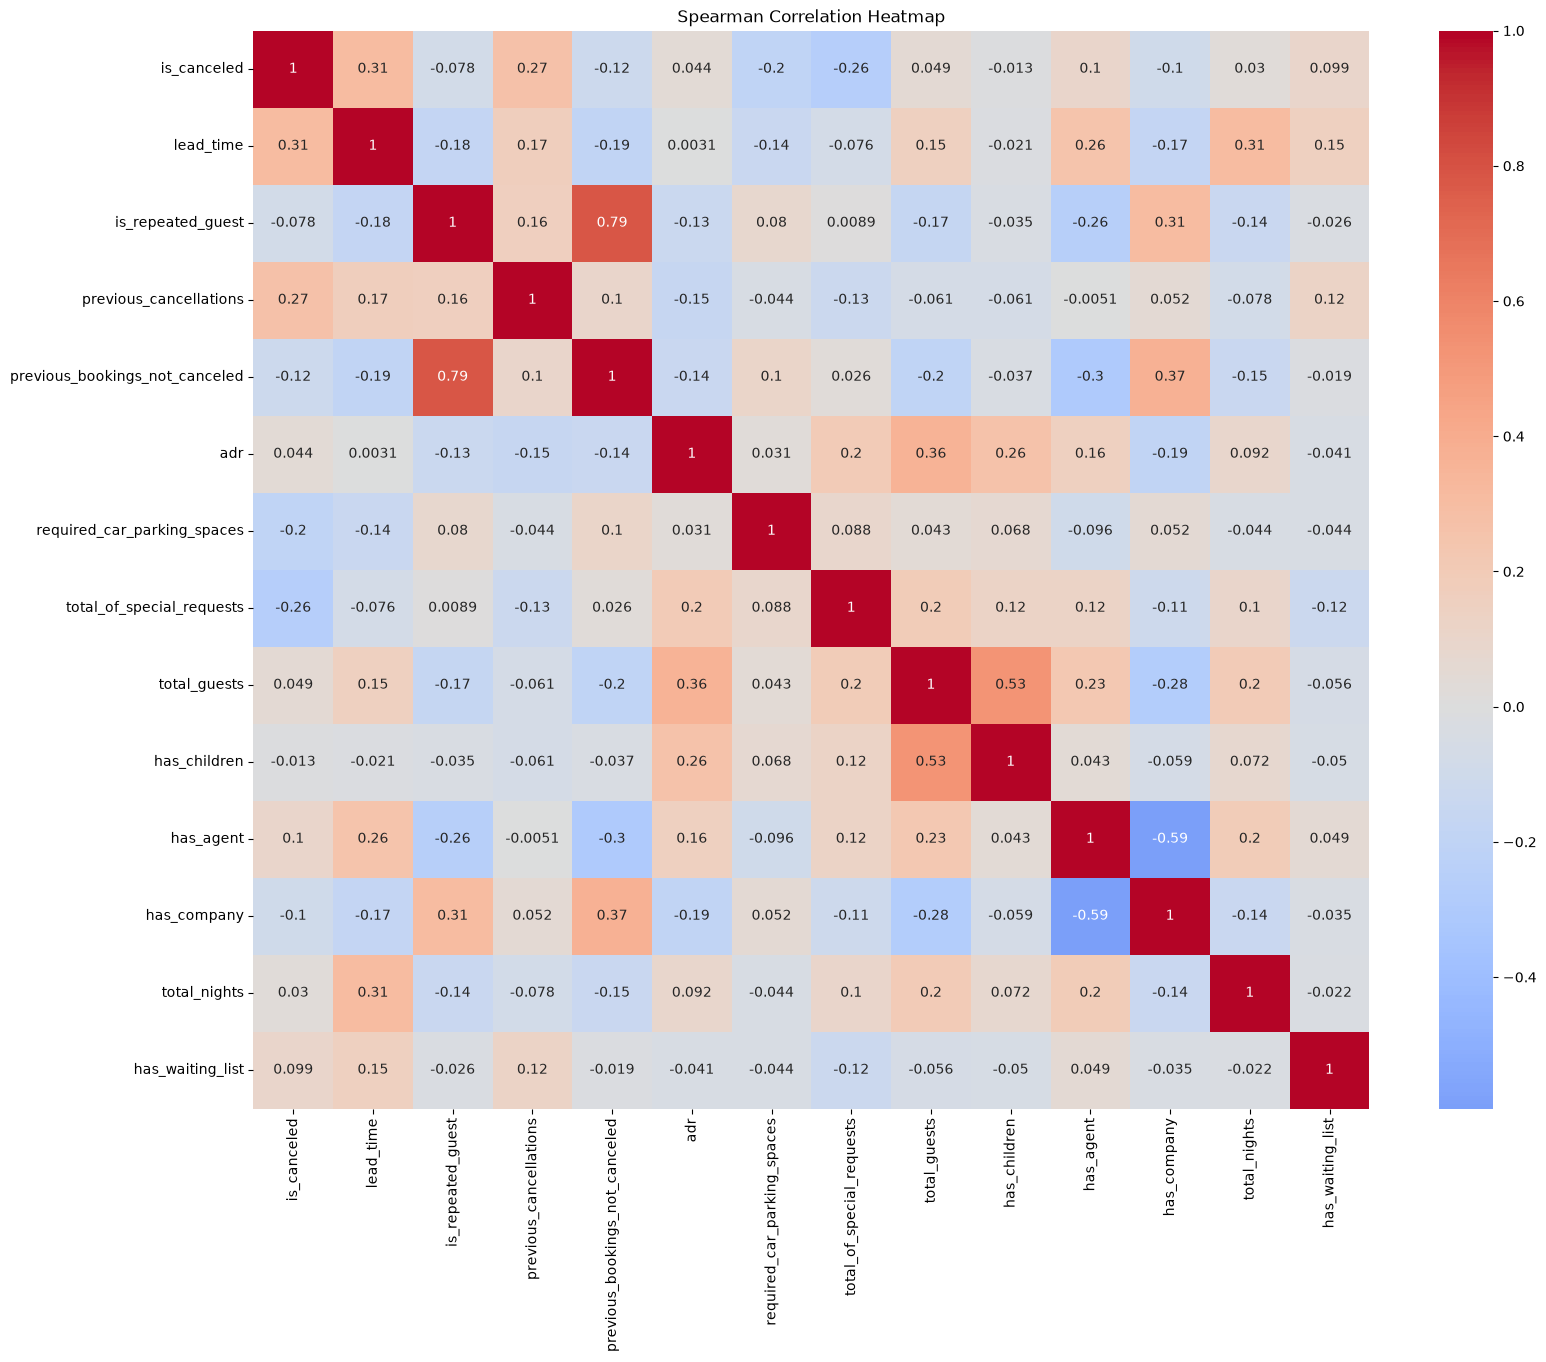

In [21]:
plt.figure(figsize=(18, 14))

corr = numeric_df.corr(method="spearman")

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True
)

plt.title("Spearman Correlation Heatmap")
plt.show()

In [22]:
cancel_corr = (
    corr["is_canceled"]
    .drop("is_canceled")
    .sort_values(key=abs, ascending=False)
)

cancel_corr

lead_time                         0.314588
previous_cancellations            0.270107
total_of_special_requests        -0.260177
required_car_parking_spaces      -0.198726
previous_bookings_not_canceled   -0.115706
has_agent                         0.101080
has_company                      -0.099721
has_waiting_list                  0.098765
is_repeated_guest                -0.077793
total_guests                      0.049323
adr                               0.043862
total_nights                      0.030425
has_children                     -0.013201
Name: is_canceled, dtype: float64

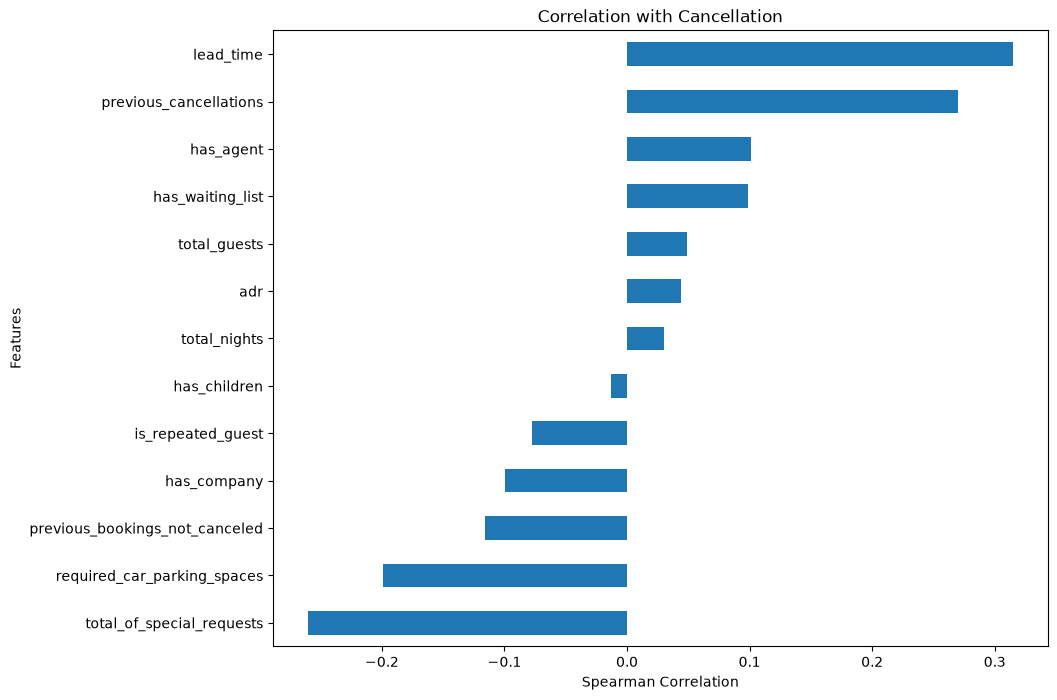

In [23]:
plt.figure(figsize=(10, 8))

cancel_corr.sort_values().plot(kind="barh")

plt.title("Correlation with Cancellation")
plt.xlabel("Spearman Correlation")
plt.ylabel("Features")
plt.show()

In [18]:
# 범주형 변수
categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "country_group",
    "market_segment",
    "reserved_room_type",
    "customer_type"
]

In [25]:
# 범주형 변수 컬럼 수 확인
for col in categorical_cols:
    print(f"{col}: {df2[col].nunique()}개")

hotel: 2개
arrival_date_month: 12개
meal: 5개
country_group: 11개
market_segment: 8개
reserved_room_type: 9개
customer_type: 4개


In [26]:
for col in categorical_cols:
    print(f"\n===== {col} =====")

    result = (
        df2.groupby(col)["is_canceled"]
        .agg(["count", "mean"])
        .sort_values("count", ascending=False)
    )

    display(result)


===== hotel =====


,count,mean
hotel,,
City Hotel,78897,0.419103
Resort Hotel,39665,0.280071



===== arrival_date_month =====


,count,mean
arrival_date_month,,
August,13812,0.379163
July,12585,0.376242
May,11704,0.399436
October,11063,0.383711
April,11045,0.408782
June,10891,0.416123
September,10477,0.392670
March,9716,0.323796
February,7998,0.335834



===== meal =====


...

,count,mean
market_segment,,
Online TA,56128,0.369210
Offline TA/TO,24048,0.345143
Groups,19759,0.612025
Direct,12449,0.155033
Corporate,5230,0.189101
Complementary,715,0.121678
Aviation,231,0.220779
Undefined,2,1.000000



===== reserved_room_type =====


,count,mean
reserved_room_type,,
A,85397,0.393538
D,19094,0.319315
E,6482,0.294199
F,2879,0.305662
G,2074,0.367888
B,1110,0.330631
C,923,0.332611
H,597,0.410385
L,6,0.333333



===== customer_type =====


,count,mean
customer_type,,
Transient,88934,0.410113
Transient-Party,25004,0.255279
Contract,4055,0.310974
Group,569,0.101933


### 머신러닝 시작

In [19]:
categorical_cols = [
    "hotel",
    "arrival_date_month",
    "meal",
    "market_segment",
    "reserved_room_type",
    "customer_type",
    "country_group"
]

numeric_cols = [
    "lead_time",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "has_agent",
    "has_company",
    "total_guests",
    "total_nights",
    "has_waiting_list",
    "has_children"
]

feature_cols = categorical_cols + numeric_cols

In [20]:
print("Feature 수:", len(feature_cols))
print(feature_cols)

Feature 수: 20
['hotel', 'arrival_date_month', 'meal', 'market_segment', 'reserved_room_type', 'customer_type', 'country_group', 'lead_time', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'has_agent', 'has_company', 'total_guests', 'total_nights', 'has_waiting_list', 'has_children']


In [21]:
# 학습 데이터 분리
X = df2[feature_cols]
y = df2["is_canceled"]

In [30]:
print("X:", X.shape)
print("y:", y.shape)

print("\nTarget 분포")
print(y.value_counts())
print(y.value_counts(normalize=True))

X: (118562, 20)
y: (118562,)

Target 분포
is_canceled
0    74387
1    44175
Name: count, dtype: int64
is_canceled
0    0.62741
1    0.37259
Name: proportion, dtype: float64


In [22]:
# Train / Test 분리
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\n전체 취소율")
print(y.mean())

print("Train 취소율")
print(y_train.mean())

print("Test 취소율")
print(y_test.mean())

X_train: (94849, 20)
X_test : (23713, 20)

전체 취소율
0.3725898685919603
Train 취소율
0.3725922255374332
Test 취소율
0.37258044110825284


In [23]:
# One-Hot Encoding + Scaling 준비

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [34]:
# 범주형
categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [35]:
# 수치형
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

In [36]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [37]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("변환 전 X_train:", X_train.shape)
print("변환 후 X_train:", X_train_processed.shape)

print("변환 전 X_test:", X_test.shape)
print("변환 후 X_test:", X_test_processed.shape)

변환 전 X_train: (94849, 20)
변환 후 X_train: (94849, 64)
변환 전 X_test: (23713, 20)
변환 후 X_test: (23713, 64)


In [38]:
processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print("전처리 후 Feature 수:", len(processed_feature_names))
print(processed_feature_names)

전처리 후 Feature 수: 64
['num__lead_time' 'num__is_repeated_guest' 'num__previous_cancellations'
 'num__previous_bookings_not_canceled' 'num__adr'
 'num__required_car_parking_spaces' 'num__total_of_special_requests'
 'num__has_agent' 'num__has_company' 'num__total_guests'
 'num__total_nights' 'num__has_waiting_list' 'num__has_children'
 'cat__hotel_City Hotel' 'cat__hotel_Resort Hotel'
 'cat__arrival_date_month_April' 'cat__arrival_date_month_August'
 'cat__arrival_date_month_December' 'cat__arrival_date_month_February'
 'cat__arrival_date_month_January' 'cat__arrival_date_month_July'
 'cat__arrival_date_month_June' 'cat__arrival_date_month_March'
 'cat__arrival_date_month_May' 'cat__arrival_date_month_November'
 'cat__arrival_date_month_October' 'cat__arrival_date_month_September'
 'cat__meal_BB' 'cat__meal_FB' 'cat__meal_HB' 'cat__meal_SC'
 'cat__meal_Undefined' 'cat__market_segment_Aviation'
 'cat__market_segment_Complementary' 'cat__market_segment_Corporate'
 'cat__market_segment_Direc

In [39]:
# 로지스틱 회귀
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [40]:
lr_pipeline.fit(X_train, y_train)
y_pred = lr_pipeline.predict(X_test)
y_proba = lr_pipeline.predict_proba(X_test)[:, 1]

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.802
Precision: 0.7742
Recall   : 0.6613
F1 Score : 0.7133
ROC-AUC  : 0.8772

Confusion Matrix
[[13174  1704]
 [ 2992  5843]]


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85     14878
           1       0.77      0.66      0.71      8835

    accuracy                           0.80     23713
   macro avg       0.79      0.77      0.78     23713
weighted avg       0.80      0.80      0.80     23713



In [43]:
import pandas as pd

model_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": 0.8020,
        "Precision": 0.7742,
        "Recall": 0.6613,
        "F1 Score": 0.7133,
        "ROC-AUC": 0.8772
    }
])

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802,0.7742,0.6613,0.7133,0.8772


In [44]:
# 랜덤 포레스트
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200, 
        random_state=42,
        n_jobs=-1       # CPU 코어를 최대한 사용해서 학습 속도를 높이는 옵션
    ))
])

rf_pipeline.fit(X_train, y_train);

In [45]:
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

In [46]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

Accuracy : 0.878
Precision: 0.862
Recall   : 0.8006
F1 Score : 0.8302
ROC-AUC  : 0.9481

Confusion Matrix
[[13746  1132]
 [ 1762  7073]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.92      0.90     14878
           1       0.86      0.80      0.83      8835

    accuracy                           0.88     23713
   macro avg       0.87      0.86      0.87     23713
weighted avg       0.88      0.88      0.88     23713



In [47]:
new_result = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1,
        "ROC-AUC": rf_roc_auc
    }
])

model_results = pd.concat(
    [model_results, new_result],
    ignore_index=True
)

display(model_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802,0.7742,0.6613,0.7133,0.8772
1,Random Forest,0.878,0.8620,0.8006,0.8302,0.9481


In [48]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,       # 앞의 트리가 틀린 부분을 뒤의 트리가 보완 
                                #  -> 랜덤 포레스트처럼 많이 늘릴 필요 없음
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train);

In [49]:
gb_pred = gb_pipeline.predict(X_test)
gb_proba = gb_pipeline.predict_proba(X_test)[:, 1]

In [50]:
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_proba)

print("Accuracy :", round(gb_accuracy, 4))
print("Precision:", round(gb_precision, 4))
print("Recall   :", round(gb_recall, 4))
print("F1 Score :", round(gb_f1, 4))
print("ROC-AUC  :", round(gb_roc_auc, 4))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, gb_pred))

print("\nClassification Report")
print(classification_report(y_test, gb_pred))

Accuracy : 0.831
Precision: 0.7997
Recall   : 0.7289
F1 Score : 0.7627
ROC-AUC  : 0.9104

Confusion Matrix
[[13265  1613]
 [ 2395  6440]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87     14878
           1       0.80      0.73      0.76      8835

    accuracy                           0.83     23713
   macro avg       0.82      0.81      0.82     23713
weighted avg       0.83      0.83      0.83     23713



In [51]:
new_result = pd.DataFrame([
    {
        "Model": "Gradient Boosting",
        "Accuracy": gb_accuracy,
        "Precision": gb_precision,
        "Recall": gb_recall,
        "F1 Score": gb_f1,
        "ROC-AUC": gb_roc_auc
    }
])

model_results = pd.concat(
    [model_results, new_result],
    ignore_index=True
)

display(model_results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802,0.7742,0.6613,0.7133,0.8772
1,Random Forest,0.878,0.8620,0.8006,0.8302,0.9481
2,Gradient Boosting,0.831,0.7997,0.7289,0.7627,0.9104


In [52]:
# 결과 csv로 저장
model_results.to_csv(
    "model_results.csv",
    index=False,
    encoding="utf-8-sig"
)

In [53]:
# 랜덤포레스트 과적합 여부 확인

rf_train_pred = rf_pipeline.predict(X_train)
rf_train_proba = rf_pipeline.predict_proba(X_train)[:, 1]

rf_train_accuracy = accuracy_score(y_train, rf_train_pred)
rf_train_roc_auc = roc_auc_score(y_train, rf_train_proba)

print("Train Accuracy:", round(rf_train_accuracy, 4))
print("Test Accuracy :", round(rf_accuracy, 4))

print("Train ROC-AUC :", round(rf_train_roc_auc, 4))
print("Test ROC-AUC  :", round(rf_roc_auc, 4))

Train Accuracy: 0.9947
Test Accuracy : 0.878
Train ROC-AUC : 0.9995
Test ROC-AUC  : 0.9481


In [54]:
# 하이퍼파라미터 튜닝
# GridSearchCV 대신 RandomizedSearchCV
#   데이터가 9만 건 넘고, Random Forest 자체도 계산량이 있어서 
#   GridSearch를 크게 잡으면 시간이 오래걸림
# 1차 Broad RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV

param_dist_broad = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [8, 10, 12, 15, None],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2"] 
    # log2 : 랜덤 포레스트에서 각 트리가 분할(split)을 만들 때 고려할 특성(feature)의 개수
}

search_broad = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_broad,
    n_iter=12, 
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_broad.fit(X_train, y_train);


Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [55]:
print(search_broad.best_params_)
print(search_broad.best_score_)

{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': None}
0.9411691058965528


In [56]:
# search_broad 최적 모델 성능 확인
broad_rf = search_broad.best_estimator_

broad_train_pred = broad_rf.predict(X_train)
broad_train_proba = broad_rf.predict_proba(X_train)[:, 1]

broad_test_pred = broad_rf.predict(X_test)
broad_test_proba = broad_rf.predict_proba(X_test)[:, 1]

print("Train Accuracy:", round(accuracy_score(y_train, broad_train_pred), 4))
print("Test Accuracy :", round(accuracy_score(y_test, broad_test_pred), 4))

print("Train ROC-AUC :", round(roc_auc_score(y_train, broad_train_proba), 4))
print("Test ROC-AUC  :", round(roc_auc_score(y_test, broad_test_proba), 4))

print("Precision     :", round(precision_score(y_test, broad_test_pred), 4))
print("Recall        :", round(recall_score(y_test, broad_test_pred), 4))
print("F1 Score      :", round(f1_score(y_test, broad_test_pred), 4))

Train Accuracy: 0.9336
Test Accuracy : 0.872
Train ROC-AUC : 0.9878
Test ROC-AUC  : 0.9463
Precision     : 0.8627
Recall        : 0.7808
F1 Score      : 0.8197


In [57]:
# 과적합 완화를 위한 규제 범위 탐색
from sklearn.model_selection import RandomizedSearchCV

param_dist_regularized = {
    "model__n_estimators": [150, 200, 300],
    "model__max_depth": [8, 10, 12, 15, 20],
    "model__min_samples_split": [5, 10, 20],
    "model__min_samples_leaf": [2, 5, 10],
    "model__max_features": ["sqrt", "log2"]
}

search_regularized = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist_regularized,
    n_iter=12,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_regularized.fit(X_train, y_train);

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [58]:
print(search_regularized.best_params_)
print(search_regularized.best_score_)

{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 20}
0.9331107836884206


In [59]:
# 규제 search 최적 모델 성능 확인
regularized_rf = search_regularized.best_estimator_

reg_train_pred = regularized_rf.predict(X_train)
reg_train_proba = regularized_rf.predict_proba(X_train)[:, 1]

reg_test_pred = regularized_rf.predict(X_test)
reg_test_proba = regularized_rf.predict_proba(X_test)[:, 1]

print("Train Accuracy:", round(accuracy_score(y_train, reg_train_pred), 4))
print("Test Accuracy :", round(accuracy_score(y_test, reg_test_pred), 4))

print("Train ROC-AUC :", round(roc_auc_score(y_train, reg_train_proba), 4))
print("Test ROC-AUC  :", round(roc_auc_score(y_test, reg_test_proba), 4))

print("Precision     :", round(precision_score(y_test, reg_test_pred), 4))
print("Recall        :", round(recall_score(y_test, reg_test_pred), 4))
print("F1 Score      :", round(f1_score(y_test, reg_test_pred), 4))


Train Accuracy: 0.8751
Test Accuracy : 0.8598
Train ROC-AUC : 0.9564
Test ROC-AUC  : 0.9363
Precision     : 0.866
Recall        : 0.738
F1 Score      : 0.7969


In [60]:
# Random Forest 과적합 비교 결과 저장
rf_overfitting_results = pd.DataFrame([
    {
        "Model": "Random Forest - Baseline",
        "Train Accuracy": rf_train_accuracy,
        "Test Accuracy": rf_accuracy,
        "Train ROC-AUC": rf_train_roc_auc,
        "Test ROC-AUC": rf_roc_auc,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1 Score": rf_f1
    },
    {
        "Model": "Random Forest - Broad RandomizedSearchCV",
        "Train Accuracy": accuracy_score(y_train, broad_train_pred),
        "Test Accuracy": accuracy_score(y_test, broad_test_pred),
        "Train ROC-AUC": roc_auc_score(y_train, broad_train_proba),
        "Test ROC-AUC": roc_auc_score(y_test, broad_test_proba),
        "Precision": precision_score(y_test, broad_test_pred),
        "Recall": recall_score(y_test, broad_test_pred),
        "F1 Score": f1_score(y_test, broad_test_pred)
    },
    {
        "Model": "Random Forest - Regularized Search",
        "Train Accuracy": accuracy_score(y_train, reg_train_pred),
        "Test Accuracy": accuracy_score(y_test, reg_test_pred),
        "Train ROC-AUC": roc_auc_score(y_train, reg_train_proba),
        "Test ROC-AUC": roc_auc_score(y_test, reg_test_proba),
        "Precision": precision_score(y_test, reg_test_pred),
        "Recall": recall_score(y_test, reg_test_pred),
        "F1 Score": f1_score(y_test, reg_test_pred)
    }
])

display(rf_overfitting_results.round(4))

,Model,Train Accuracy,Test Accuracy,Train ROC-AUC,Test ROC-AUC,Precision,Recall,F1 Score
0,Random Forest - Baseline,0.9947,0.8780,0.9995,0.9481,0.8620,0.8006,0.8302
1,Random Forest - Broad RandomizedSearchCV,0.9336,0.8720,0.9878,0.9463,0.8627,0.7808,0.8197
2,Random Forest - Regularized Search,0.8751,0.8598,0.9564,0.9363,0.8660,0.7380,0.7969


In [61]:
rf_overfitting_results.to_csv(
    "rf_overfitting_results.csv",
    index=False,
    encoding="utf-8-sig"
)

In [62]:
# Permutation Importance
# Train을 다시 Sub-train / Validation으로 분리
from sklearn.model_selection import train_test_split
from sklearn.base import clone

X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [63]:
# 현재 최종 후보인 규제 Random Forest를 복제해서 다시 학습
rf_for_importance = clone(regularized_rf)

rf_for_importance.fit(
    X_subtrain,
    y_subtrain
);

In [64]:
# 최종 모델을 평가할 때 중요하게 본 ROC-AUC가 
# 각 Feature를 섞었을 때 얼마나 떨어지는지 확인

from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_for_importance,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

In [65]:
importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df)

,Feature,Importance,Std
0,country_group,0.144925,0.001802
1,market_segment,0.066426,0.000982
2,customer_type,0.057091,0.000698
3,total_of_special_requests,0.052880,0.001359
4,lead_time,0.051438,0.000863
5,required_car_parking_spaces,0.020054,0.001399
6,previous_cancellations,0.014743,0.000596
7,adr,0.014404,0.000447
8,arrival_date_month,0.009906,0.000305
9,hotel,0.009761,0.000567


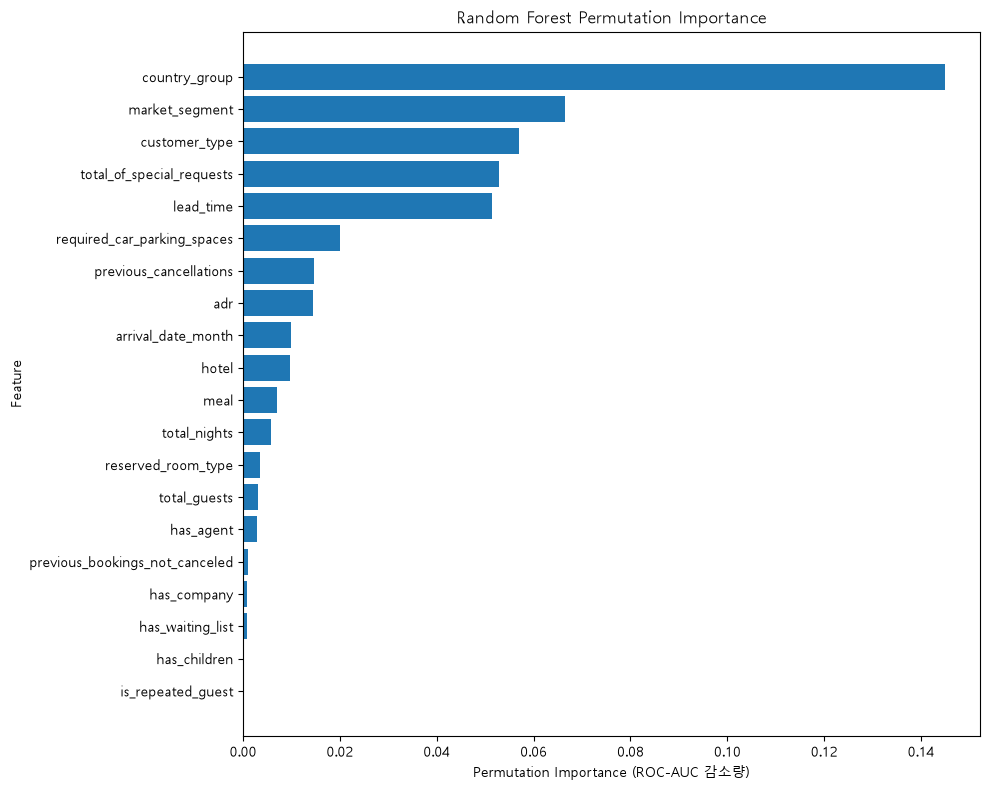

In [66]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

plt.figure(figsize=(10, 8))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Permutation Importance (ROC-AUC 감소량)")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [67]:
# Feature 축소 실험
drop_features = [
    "is_repeated_guest"
]

X_train_reduced = X_train.drop(columns=drop_features)

numeric_cols_reduced = [
    col for col in numeric_cols
    if col not in drop_features
]

In [68]:
preprocessor_reduced = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols_reduced),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_reduced = Pipeline([
    ("preprocessor", preprocessor_reduced),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=2,
        max_features="log2",
        random_state=42,
        n_jobs=-1
    ))
])

rf_reduced.fit(
    X_subtrain,
    y_subtrain
);

In [70]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_val_pred = rf_reduced.predict(X_val)
y_val_proba = rf_reduced.predict_proba(X_val)[:, 1]

print("Validation Accuracy :", accuracy_score(y_val, y_val_pred))
print("Validation Precision:", precision_score(y_val, y_val_pred))
print("Validation Recall   :", recall_score(y_val, y_val_pred))
print("Validation F1       :", f1_score(y_val, y_val_pred))
print("Validation ROC-AUC  :", roc_auc_score(y_val, y_val_proba))

Validation Accuracy : 0.8542435424354243
Validation Precision: 0.8603249037012226
Validation Recall   : 0.726796830786644
Validation F1       : 0.7879438607255158
Validation ROC-AUC  : 0.9331282879699397


In [71]:
X_subtrain_full, X_val_full, y_subtrain_full, y_val_full = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [72]:
preprocessor_full = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [73]:
rf_full = Pipeline([
    ("preprocessor", preprocessor_full),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=2,
        max_features="log2",
        random_state=42,
        n_jobs=-1
    ))
])

rf_full.fit(X_subtrain_full, y_subtrain_full);

In [74]:
y_val_full_pred = rf_full.predict(X_val_full)
y_val_full_proba = rf_full.predict_proba(X_val_full)[:, 1]

print("20 Feature Accuracy :", accuracy_score(y_val_full, y_val_full_pred))
print("20 Feature Precision:", precision_score(y_val_full, y_val_full_pred))
print("20 Feature Recall   :", recall_score(y_val_full, y_val_full_pred))
print("20 Feature F1       :", f1_score(y_val_full, y_val_full_pred))
print("20 Feature ROC-AUC  :", roc_auc_score(y_val_full, y_val_full_proba))

20 Feature Accuracy : 0.8570901423299947
20 Feature Precision: 0.8594291371060881
20 Feature Recall   : 0.7369835880022637
20 Feature F1       : 0.7935105491659684
20 Feature ROC-AUC  : 0.9345547886973955


In [75]:
# 강한 규제와 Baseline 사이의 중간값을 찾기 위해 수동으로 완화된 규제 적용
rf_moderate = Pipeline([
    ("preprocessor", preprocessor_full),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="log2",
        random_state=42,
        n_jobs=-1
    ))
])

rf_moderate.fit(X_subtrain_full, y_subtrain_full);

In [76]:
y_val_pred = rf_moderate.predict(X_val_full)
y_val_proba = rf_moderate.predict_proba(X_val_full)[:, 1]

print("Accuracy :", accuracy_score(y_val_full, y_val_pred))
print("Precision:", precision_score(y_val_full, y_val_pred))
print("Recall   :", recall_score(y_val_full, y_val_pred))
print("F1       :", f1_score(y_val_full, y_val_pred))
print("ROC-AUC  :", roc_auc_score(y_val_full, y_val_proba))

Accuracy : 0.8629942013705851
Precision: 0.8608105926045535
Recall   : 0.7542444821731749
F1       : 0.8040117638187165
ROC-AUC  : 0.940071961720586


In [77]:
## 모델의 성능이 약간 아쉬워 분석을 확장하고자 함 => 예약 금액과 결합하여 손실 위험도 판단

In [78]:
val_result = X_val_full.copy()

# 실제 취소 여부
val_result["actual_canceled"] = y_val_full.values

# 모델이 예측한 취소 확률
val_result["cancel_probability"] = y_val_proba

# 예상 예약 금액
val_result["booking_amount"] = (
    val_result["adr"] * val_result["total_nights"]
)

# 예상 손실 위험액
val_result["expected_loss"] = (
    val_result["cancel_probability"]
    * val_result["booking_amount"]
)

In [79]:
val_result[
    [
        "adr",
        "total_nights",
        "booking_amount",
        "cancel_probability",
        "expected_loss",
        "actual_canceled"
    ]
].sort_values(
    "expected_loss",
    ascending=False
).head(10)

,adr,total_nights,booking_amount,cancel_probability,expected_loss,actual_canceled
13142,450.00,14,6300.00,0.837974,5279.235483,1
60133,212.00,29,6148.00,0.596947,3670.030070,1
62583,140.00,30,4200.00,0.773669,3249.408429,1
64375,231.81,21,4868.01,0.550765,2681.128564,1
7407,259.00,14,3626.00,0.734309,2662.605939,1
53846,244.43,14,3422.02,0.700932,2398.603310,1
62891,159.80,19,3036.20,0.761275,2311.383171,1
62244,96.90,30,2907.00,0.792533,2303.893118,1
26661,234.17,14,3278.38,0.690064,2262.292452,0
12815,183.05,16,2928.80,0.737698,2160.570783,1


In [80]:
# 위험도 : 상위 25% high / 50~75% midium / 하위 50% low 등급화
q50 = val_result["expected_loss"].quantile(0.50)
q75 = val_result["expected_loss"].quantile(0.75)

def risk_level(loss):
    if loss >= q75:
        return "HIGH"
    elif loss >= q50:
        return "MEDIUM"
    else:
        return "LOW"

val_result["risk_level"] = val_result["expected_loss"].apply(risk_level)

In [81]:
val_result[
    [
        "cancel_probability",
        "booking_amount",
        "expected_loss",
        "risk_level"
    ]
].sort_values(
    "expected_loss",
    ascending=False
).head(10)

,cancel_probability,booking_amount,expected_loss,risk_level
13142,0.837974,6300.00,5279.235483,HIGH
60133,0.596947,6148.00,3670.030070,HIGH
62583,0.773669,4200.00,3249.408429,HIGH
64375,0.550765,4868.01,2681.128564,HIGH
7407,0.734309,3626.00,2662.605939,HIGH
53846,0.700932,3422.02,2398.603310,HIGH
62891,0.761275,3036.20,2311.383171,HIGH
62244,0.792533,2907.00,2303.893118,HIGH
26661,0.690064,3278.38,2262.292452,HIGH
12815,0.737698,2928.80,2160.570783,HIGH


In [82]:
risk_summary = (
    val_result
    .groupby("risk_level")
    .agg(
        reservations=("actual_canceled", "count"),
        actual_cancel_rate=("actual_canceled", "mean"),
        avg_cancel_probability=("cancel_probability", "mean"),
        avg_booking_amount=("booking_amount", "mean"),
        avg_expected_loss=("expected_loss", "mean")
    )
)

display(risk_summary.round(3))

,reservations,actual_cancel_rate,avg_cancel_probability,avg_booking_amount,avg_expected_loss
risk_level,,,,,
HIGH,4743,0.745,0.699,630.339,387.696
LOW,9485,0.103,0.136,237.949,22.269
MEDIUM,4742,0.538,0.527,333.575,124.273


In [83]:
val_result.to_csv(
    "validation_loss_risk.csv",
    index=False,
    encoding="utf-8-sig"
)

In [84]:
# 위험등급 기준값 고정
print("q50:", q50)
print("q75:", q75)

q50: 73.91580054016089
q75: 186.1786367944846


In [85]:
# 최종 모델 학습
final_model = Pipeline([
    ("preprocessor", preprocessor_full),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=25,
        min_samples_leaf=2,
        min_samples_split=5,
        max_features="log2",
        random_state=42,
        n_jobs=1
    ))
])

final_model.fit(X_train, y_train);

In [86]:
# 최종 테스트 데이터 평가
final_test_pred = final_model.predict(X_test)
final_test_proba = final_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, final_test_pred), 4))
print("Precision:", round(precision_score(y_test, final_test_pred), 4))
print("Recall:", round(recall_score(y_test, final_test_pred), 4))
print("F1:", round(f1_score(y_test, final_test_pred), 4))
print("ROC-AUC", round(roc_auc_score(y_test, final_test_proba), 4))

Accuracy: 0.8663
Precision: 0.867
Recall: 0.7573
F1: 0.8085
ROC-AUC 0.942


In [87]:
# 최종 모델 테스트 성능 저장

def evaluate_rf_model(name, model):
    train_pred = model.predict(X_train)
    train_proba = model.predict_proba(X_train)[:, 1]

    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Train ROC-AUC": roc_auc_score(y_train, train_proba),
        "Test ROC-AUC": roc_auc_score(y_test, test_proba),
        "Precision": precision_score(y_test, test_pred),
        "Recall": recall_score(y_test, test_pred),
        "F1 Score": f1_score(y_test, test_pred)
    }


rf_overfitting_results = pd.DataFrame([
    evaluate_rf_model(
        "Random Forest - Baseline",
        rf_pipeline
    ),
    evaluate_rf_model(
        "Random Forest - Broad RandomizedSearchCV",
        broad_rf
    ),
    evaluate_rf_model(
        "Random Forest - Regularized Search",
        regularized_rf
    ),
    evaluate_rf_model(
        "Random Forest - Moderate Final",
        final_model
    )
])

display(rf_overfitting_results.round(4))

,Model,Train Accuracy,Test Accuracy,Train ROC-AUC,Test ROC-AUC,Precision,Recall,F1 Score
0,Random Forest - Baseline,0.9947,0.8780,0.9995,0.9481,0.8620,0.8006,0.8302
1,Random Forest - Broad RandomizedSearchCV,0.9336,0.8720,0.9878,0.9463,0.8627,0.7808,0.8197
2,Random Forest - Regularized Search,0.8751,0.8598,0.9564,0.9363,0.8660,0.7380,0.7969
3,Random Forest - Moderate Final,0.8987,0.8663,0.9732,0.9420,0.8670,0.7573,0.8085


In [88]:
rf_overfitting_results.to_csv(
    "rf_overfitting_results.csv",
    index=False,
    encoding="utf-8-sig"
)

In [89]:
import joblib

In [90]:
# 모델 저장
import joblib

joblib.dump(final_model, "model/hotel_canceled.pkl")

['model/hotel_canceled.pkl']

In [91]:
# 위험등급 기준도 같이 저장

risk_thresholds = {
    "q50": 73.9160,
    "q75": 186.1786
}

joblib.dump(
    risk_thresholds,
    "model/risk_thresholds.pkl"
)

['model/risk_thresholds.pkl']

In [92]:
# 모델 불러오기
loaded_model = joblib.load("model/hotel_canceled.pkl")
loaded_thresholds = joblib.load("model/risk_thresholds.pkl")

print(loaded_thresholds)

{'q50': 73.916, 'q75': 186.1786}


In [93]:
# 모델 동작 확인
loaded_pred = loaded_model.predict(X_test)
loaded_proba = loaded_model.predict_proba(X_test)[:, 1]

print(
    "Accuracy:",
    round(accuracy_score(y_test, loaded_pred), 4)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, loaded_proba), 4)
)

Accuracy: 0.8663
ROC-AUC: 0.942


In [94]:
# 변수 테스트

In [95]:
X_repeat_0 = X_test.copy()
X_repeat_1 = X_test.copy()

X_repeat_0["is_repeated_guest"] = 0
X_repeat_1["is_repeated_guest"] = 1

prob_repeat_0 = final_model.predict_proba(X_repeat_0)[:, 1]
prob_repeat_1 = final_model.predict_proba(X_repeat_1)[:, 1]

print("재방문 X 평균 취소확률:", prob_repeat_0.mean())
print("재방문 O 평균 취소확률:", prob_repeat_1.mean())
print("평균 변화량:", (prob_repeat_1 - prob_repeat_0).mean())

print(
    "재방문으로 확률 상승한 비율:",
    ((prob_repeat_1 - prob_repeat_0) > 0).mean()
)

재방문 X 평균 취소확률: 0.3738556495520411
재방문 O 평균 취소확률: 0.340319700220533
평균 변화량: -0.03353594933150808
재방문으로 확률 상승한 비율: 0.29629317252140175


In [96]:
import joblib
import os

model = joblib.load("model/hotel_canceled.pkl")

joblib.dump(
    model,
    "model/hotel_canceled.pkl",
    compress=3
)

size_mb = os.path.getsize(
    "model/hotel_canceled.pkl"
) / 1024**2

print(f"압축 모델 크기: {size_mb:.2f}MB")

압축 모델 크기: 44.88MB


In [ ]:
importance_df.to_csv(
    "permutation_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

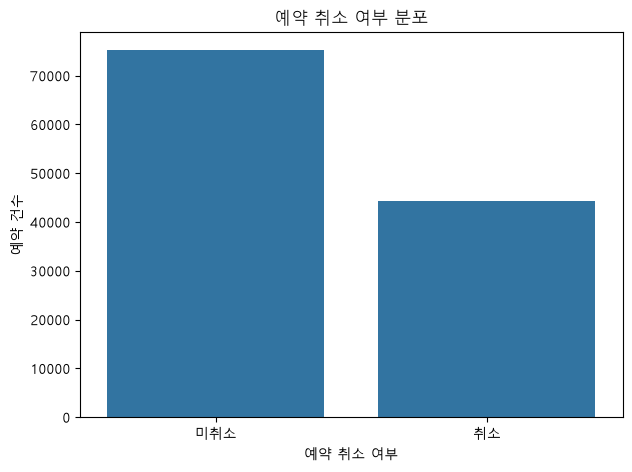

In [98]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="is_canceled"
)

plt.title("예약 취소 여부 분포")
plt.xlabel("예약 취소 여부")
plt.ylabel("예약 건수")
plt.xticks(
    [0, 1],
    ["미취소", "취소"]
)

plt.show()

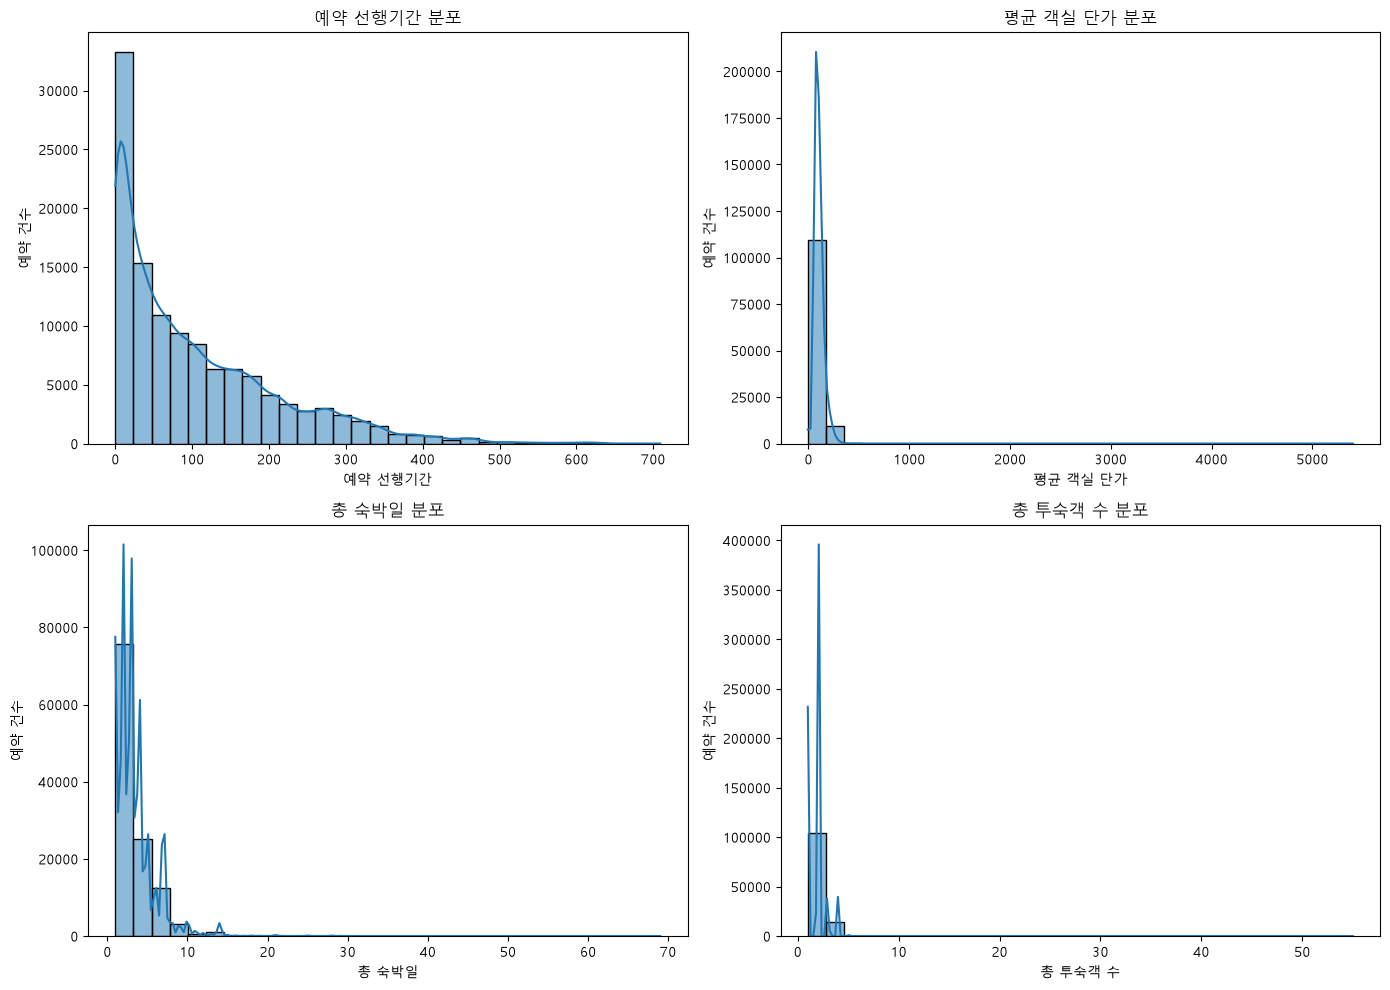

In [99]:
hist_cols = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests"
]

titles = [
    "예약 선행기간",
    "평균 객실 단가",
    "총 숙박일",
    "총 투숙객 수"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

for col, title, ax in zip(
    hist_cols,
    titles,
    axes.flatten()
):
    sns.histplot(
        data=df2,
        x=col,
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(f"{title} 분포")
    ax.set_xlabel(title)
    ax.set_ylabel("예약 건수")

plt.tight_layout()
plt.show()

In [100]:
check_cols = [
    "lead_time",
    "adr",
    "total_nights",
    "total_guests"
]

df2[check_cols].describe(
    percentiles=[
        0.90,
        0.95,
        0.99,
        0.995,
        0.999
    ]
).T

,count,mean,std,min,50%,90%,95%,99%,99.5%,99.9%,max
lead_time,118562.0,104.507608,106.916250,0.00,70.0,265.0,320.0,444.0,478.0,605.00000,709.0
adr,118562.0,102.523767,50.006063,-6.38,95.0,164.7,194.0,252.0,275.0,326.40463,5400.0
total_nights,118562.0,3.444814,2.534803,1.00,3.0,7.0,7.0,14.0,14.0,25.00000,69.0
total_guests,118562.0,1.971930,0.717539,1.00,2.0,3.0,3.0,4.0,4.0,5.00000,55.0


In [101]:
df2.nlargest(
    10,
    "adr"
)[
    [
        "hotel",
        "adr",
        "total_nights",
        "total_guests",
        "is_canceled"
    ]
]

,hotel,adr,total_nights,total_guests,is_canceled
48515,City Hotel,5400.00,1,2,1
111403,City Hotel,510.00,1,1,0
15083,Resort Hotel,508.00,1,2,0
103912,City Hotel,451.50,2,4,0
13142,Resort Hotel,450.00,14,2,1
13391,Resort Hotel,437.00,6,4,1
39155,Resort Hotel,426.25,8,4,0
39568,Resort Hotel,402.00,5,4,0
39118,Resort Hotel,397.38,8,5,0
13323,Resort Hotel,392.00,10,3,1


In [102]:
df2.nlargest(
    10,
    "total_guests"
)[
    [
        "hotel",
        "adr",
        "total_nights",
        "total_guests",
        "is_canceled"
    ]
]

,hotel,adr,total_nights,total_guests,is_canceled
2173,Resort Hotel,0.0,2,55,1
1643,Resort Hotel,0.0,3,50,1
1539,Resort Hotel,0.0,3,40,1
1917,Resort Hotel,0.0,4,27,1
1962,Resort Hotel,0.0,4,27,1
1587,Resort Hotel,0.0,7,26,1
1752,Resort Hotel,0.0,7,26,1
1884,Resort Hotel,0.0,7,26,1
2003,Resort Hotel,0.0,7,26,1
2164,Resort Hotel,0.0,7,26,1


In [ ]:
adr_outliers = df2[
    (df2["adr"] < 0)
    | (df2["adr"] > 1000)
]

adr_outliers["adr"]

14969      -6.38
48515    5400.00
Name: adr, dtype: float64

In [ ]:
# adr 이상치 처리
df2 = df2[
    (df2["adr"] >= 0)
    & (df2["adr"] <= 1000)
]

2     75.0
3     75.0
4     98.0
5     98.0
6    107.0
Name: adr, dtype: float64


In [118]:
remaining_outliers = df2[
    (df2["adr"] < 0)
    | (df2["adr"] > 1000)
]

display(remaining_outliers)

print(
    "남은 ADR 이상치:",
    len(remaining_outliers),
    "건"
)

,hotel,is_canceled,lead_time,arrival_date_month,meal,market_segment,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,...,adr,required_car_parking_spaces,total_of_special_requests,total_guests,has_children,has_agent,has_company,total_nights,has_waiting_list,country_group


남은 ADR 이상치: 0 건


In [120]:
model_results = pd.read_csv(
    "model_results.csv"
)

display(
    model_results.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802,0.7742,0.6613,0.7133,0.8772
1,Random Forest,0.878,0.8620,0.8006,0.8302,0.9481
2,Gradient Boosting,0.831,0.7997,0.7289,0.7627,0.9104


In [121]:
plot_df = model_results.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

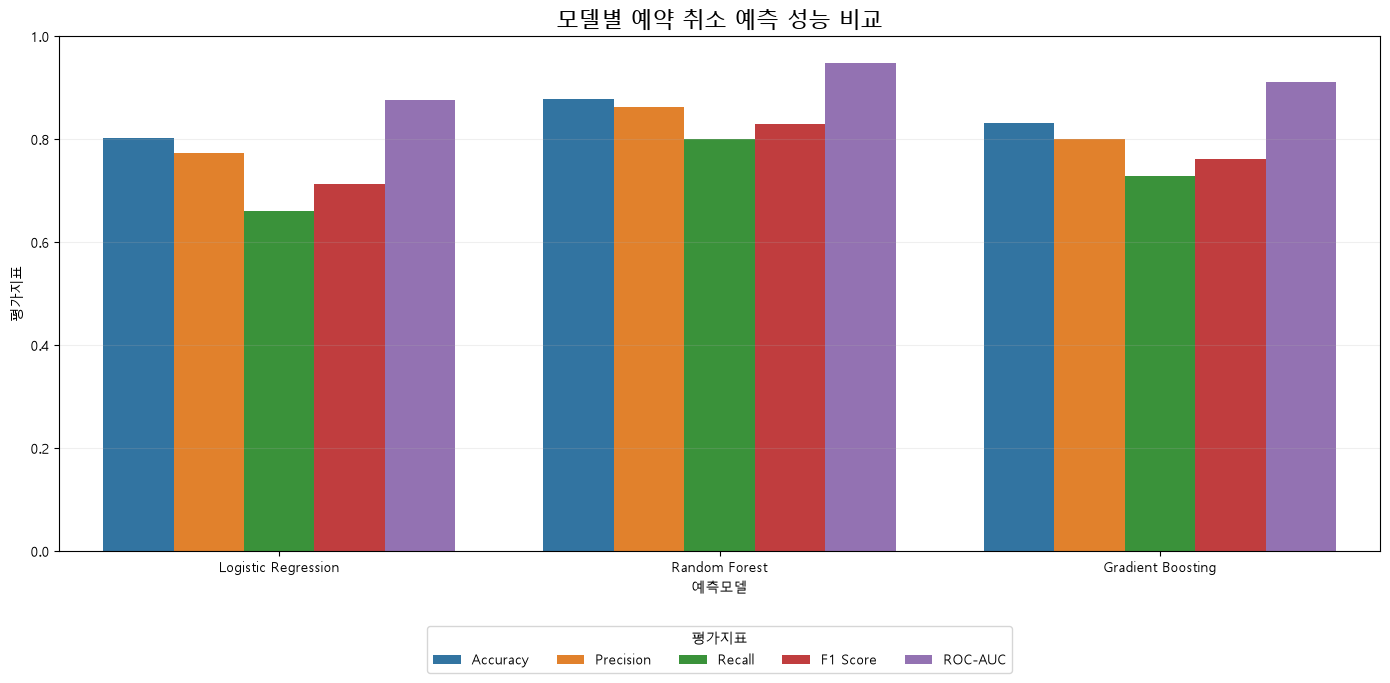

In [122]:
plt.figure(
    figsize=(14, 7)
)

ax = sns.barplot(
    data=plot_df,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "모델별 예약 취소 예측 성능 비교",
    fontsize=16
)

plt.xlabel("예측모델")
plt.ylabel("평가지표")
plt.ylim(0, 1)

plt.legend(
    title="평가지표",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=5
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [123]:
rf_results = pd.read_csv(
    "rf_overfitting_results.csv"
)

baseline_result = rf_results[
    rf_results["Model"]
    == "Random Forest - Baseline"
].iloc[0]

baseline_result

Model             Random Forest - Baseline
Train Accuracy                    0.994739
Test Accuracy                     0.877957
Train ROC-AUC                     0.999503
Test ROC-AUC                       0.94809
Precision                         0.862035
Recall                            0.800566
F1 Score                          0.830164
Name: 0, dtype: object

In [124]:
overfit_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC"
    ],

    "Train": [
        baseline_result["Train Accuracy"],
        baseline_result["Train ROC-AUC"]
    ],

    "Test": [
        baseline_result["Test Accuracy"],
        baseline_result["Test ROC-AUC"]
    ]
})

In [125]:
overfit_summary["Gap"] = (
    overfit_summary["Train"]
    - overfit_summary["Test"]
)

display(
    overfit_summary.round(4)
)

,Metric,Train,Test,Gap
0,Accuracy,0.9947,0.8780,0.1168
1,ROC-AUC,0.9995,0.9481,0.0514


In [126]:
overfit_plot = overfit_summary.melt(
    id_vars="Metric",
    value_vars=[
        "Train",
        "Test"
    ],
    var_name="Dataset",
    value_name="Score"
)

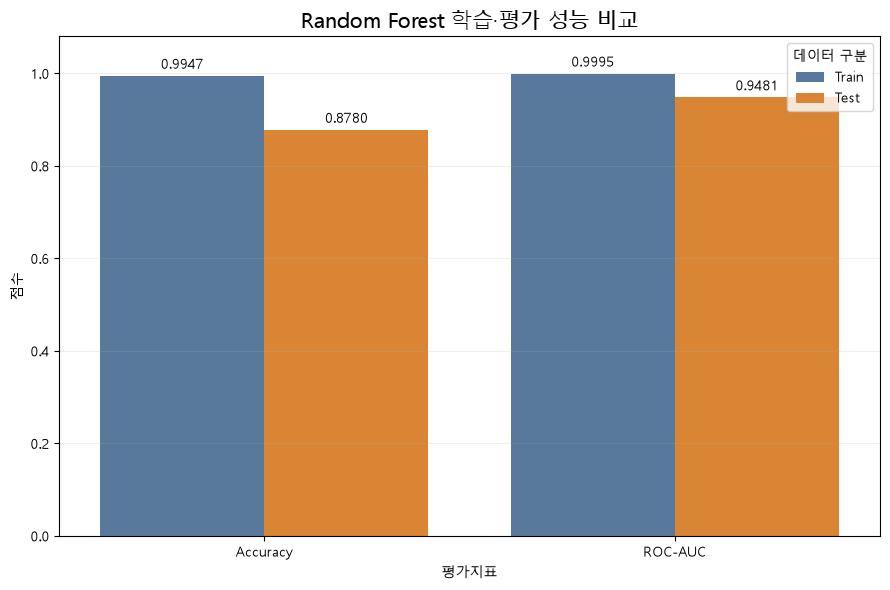

In [127]:
plt.figure(
    figsize=(9, 6)
)

ax = sns.barplot(
    data=overfit_plot,
    x="Metric",
    y="Score",
    hue="Dataset",
    palette={
        "Train": "#4C78A8",
        "Test": "#F58518"
    }
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=3
    )

plt.title(
    "Random Forest 학습·평가 성능 비교",
    fontsize=15
)

plt.xlabel("평가지표")
plt.ylabel("점수")
plt.ylim(0, 1.08)

plt.legend(
    title="데이터 구분"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    "random_forest_overfitting.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [134]:
rf_results = pd.read_csv(
    "rf_overfitting_results.csv"
)

stage_order = [
    "Random Forest - Baseline",
    "Random Forest - Broad RandomizedSearchCV",
    "Random Forest - Regularized Search"
]

# 필요한 모델만 선택하고 중복 제거
rf_curve = (
    rf_results[
        rf_results["Model"].isin(
            stage_order
        )
    ]
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
    .set_index("Model")
    .loc[stage_order]
    .reset_index()
)

In [135]:
# 표시용 단계명
rf_curve["Stage"] = [
    "Baseline",
    "1차 광범위 탐색",
    "2차 규제 탐색"
]

display(
    rf_curve[
        [
            "Stage",
            "Train ROC-AUC",
            "Test ROC-AUC"
        ]
    ].round(4)
)

,Stage,Train ROC-AUC,Test ROC-AUC
0,Baseline,0.9995,0.9481
1,1차 광범위 탐색,0.9878,0.9463
2,2차 규제 탐색,0.9564,0.9363


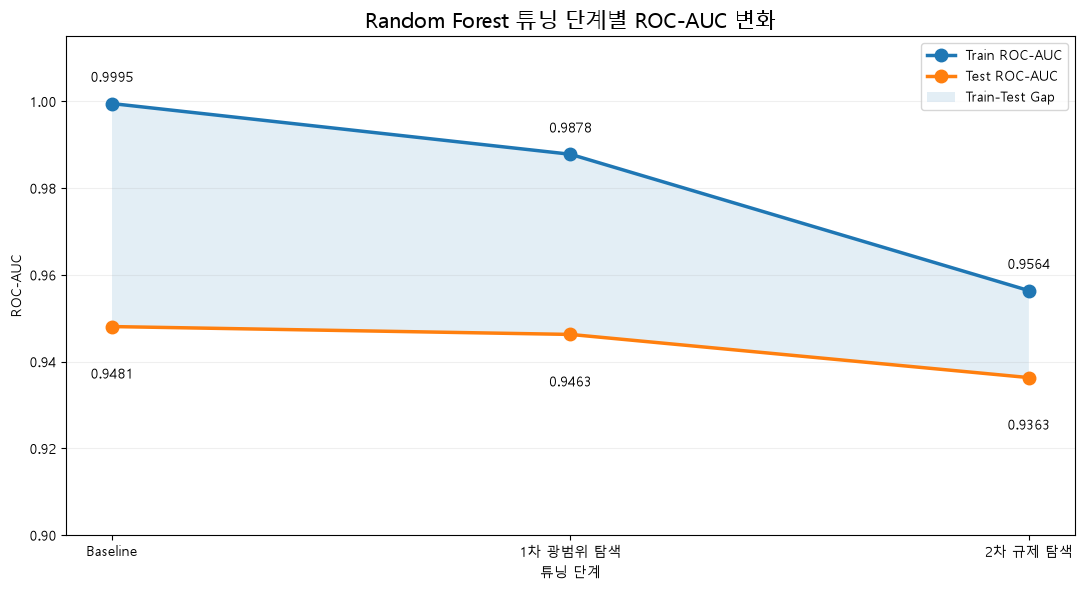

In [136]:
x = range(
    len(rf_curve)
)

plt.figure(
    figsize=(11, 6)
)

# 학습 ROC-AUC
plt.plot(
    x,
    rf_curve["Train ROC-AUC"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    label="Train ROC-AUC"
)

# 평가 ROC-AUC
plt.plot(
    x,
    rf_curve["Test ROC-AUC"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    label="Test ROC-AUC"
)

# Train-Test 간격 표시
plt.fill_between(
    x,
    rf_curve["Train ROC-AUC"],
    rf_curve["Test ROC-AUC"],
    alpha=0.12,
    label="Train-Test Gap"
)

# 점수 표시
for index, value in enumerate(
    rf_curve["Train ROC-AUC"]
):
    plt.text(
        index,
        value + 0.005,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )

for index, value in enumerate(
    rf_curve["Test ROC-AUC"]
):
    plt.text(
        index,
        value - 0.012,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )

plt.xticks(
    list(x),
    rf_curve["Stage"]
)

plt.title(
    "Random Forest 튜닝 단계별 ROC-AUC 변화",
    fontsize=15
)

plt.xlabel("튜닝 단계")
plt.ylabel("ROC-AUC")

# 성능 차이를 보기 쉽게 확대
plt.ylim(0.90, 1.015)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "random_forest_roc_auc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [137]:
rf_results = pd.read_csv(
    "rf_overfitting_results.csv"
)

stage_order = [
    "Random Forest - Baseline",
    "Random Forest - Broad RandomizedSearchCV",
    "Random Forest - Regularized Search",
    "Random Forest - Moderate Final"
]

rf_final_compare = (
    rf_results[
        rf_results["Model"].isin(
            stage_order
        )
    ]
    .drop_duplicates(
        subset="Model",
        keep="last"
    )
    .set_index("Model")
    .loc[stage_order]
    .reset_index()
)

rf_final_compare["Stage"] = [
    "Baseline",
    "1차 광범위 탐색",
    "2차 규제 탐색",
    "Moderate 최종"
]

In [138]:
display(
    rf_final_compare[
        [
            "Stage",
            "Train ROC-AUC",
            "Test ROC-AUC",
            "Precision",
            "Recall",
            "F1 Score"
        ]
    ].round(4)
)

,Stage,Train ROC-AUC,Test ROC-AUC,Precision,Recall,F1 Score
0,Baseline,0.9995,0.9481,0.8620,0.8006,0.8302
1,1차 광범위 탐색,0.9878,0.9463,0.8627,0.7808,0.8197
2,2차 규제 탐색,0.9564,0.9363,0.8660,0.7380,0.7969
3,Moderate 최종,0.9732,0.9420,0.8670,0.7573,0.8085


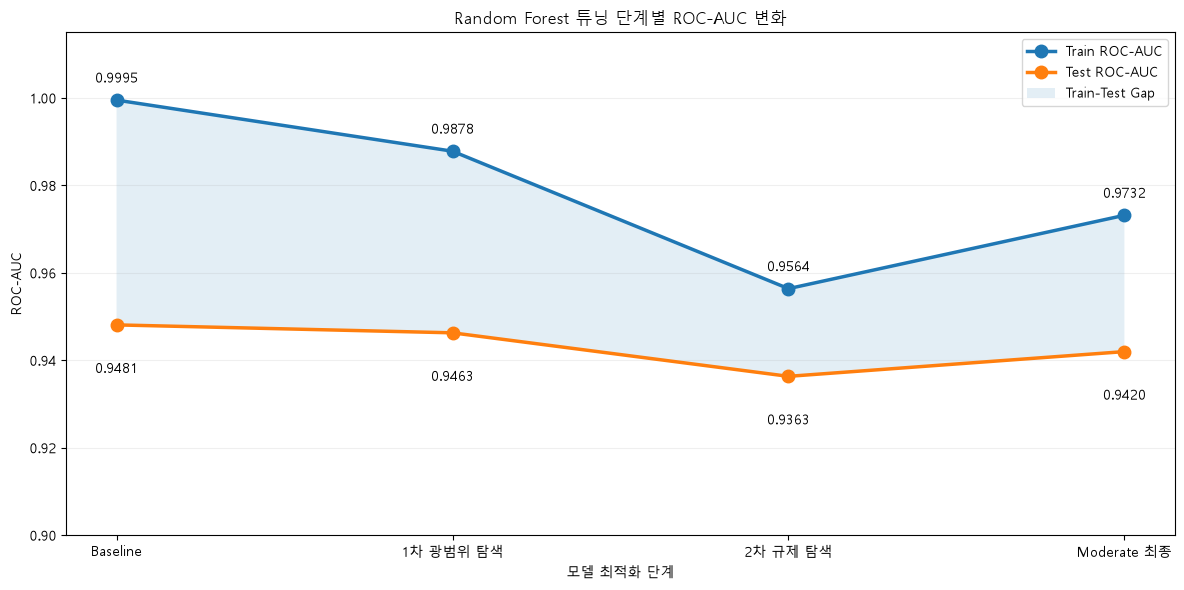

In [139]:
x = range(
    len(rf_final_compare)
)

plt.figure(
    figsize=(12, 6)
)

plt.plot(
    x,
    rf_final_compare["Train ROC-AUC"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    label="Train ROC-AUC"
)

plt.plot(
    x,
    rf_final_compare["Test ROC-AUC"],
    marker="o",
    markersize=9,
    linewidth=2.5,
    label="Test ROC-AUC"
)

plt.fill_between(
    x,
    rf_final_compare["Train ROC-AUC"],
    rf_final_compare["Test ROC-AUC"],
    alpha=0.12,
    label="Train-Test Gap"
)

for index, value in enumerate(
    rf_final_compare["Train ROC-AUC"]
):
    plt.text(
        index,
        value + 0.004,
        f"{value:.4f}",
        ha="center"
    )

for index, value in enumerate(
    rf_final_compare["Test ROC-AUC"]
):
    plt.text(
        index,
        value - 0.011,
        f"{value:.4f}",
        ha="center"
    )

plt.xticks(
    list(x),
    rf_final_compare["Stage"]
)

plt.title(
    "Random Forest 튜닝 단계별 ROC-AUC 변화"
)

plt.xlabel("모델 최적화 단계")
plt.ylabel("ROC-AUC")
plt.ylim(0.90, 1.015)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "random_forest_final_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [140]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# 검증 데이터로 변수 중요도 계산
perm_result = permutation_importance(
    rf_moderate,
    X_val_full,
    y_val_full,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_val_full.columns,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(importance_df.head(10))

,Feature,Importance,Std
0,country_group,0.146053,0.001711
1,market_segment,0.071130,0.001347
2,customer_type,0.058853,0.000673
3,total_of_special_requests,0.053100,0.001322
4,lead_time,0.052466,0.001006
5,required_car_parking_spaces,0.020011,0.001353
6,adr,0.018595,0.000525
7,previous_cancellations,0.017582,0.000661
8,arrival_date_month,0.012887,0.000360
9,hotel,0.011001,0.000498


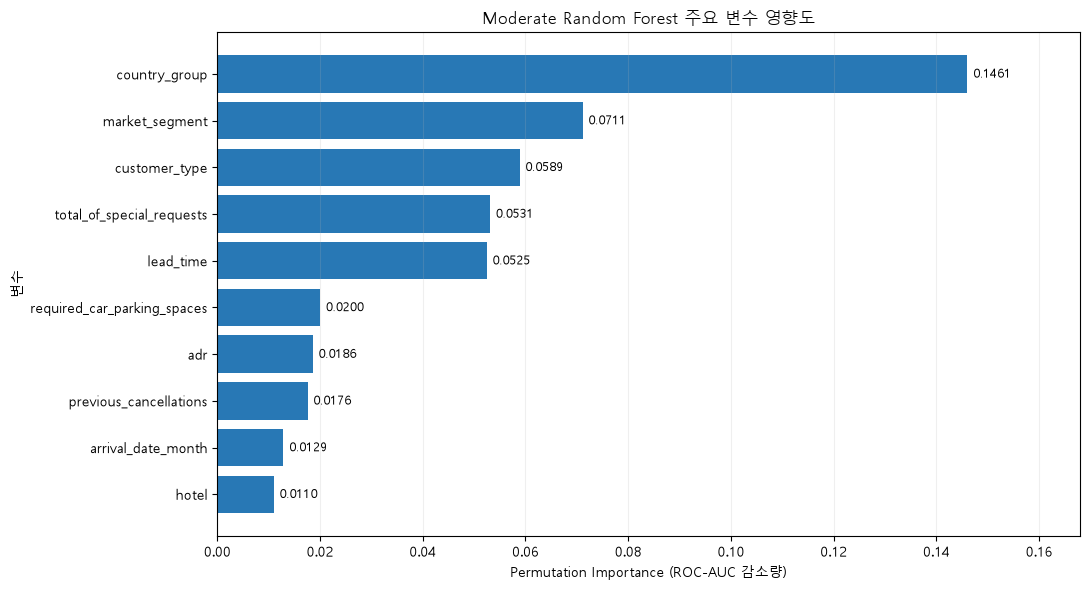

In [142]:
top10 = (
    importance_df
    .head(10)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top10["Feature"],
    top10["Importance"],
    color="#2878B5"
)

# 막대 끝에 중요도 표시
plt.bar_label(
    bars,
    fmt="%.4f",
    padding=4,
    fontsize=9
)

plt.xlabel("Permutation Importance (ROC-AUC 감소량)")
plt.ylabel("변수")
plt.title("Moderate Random Forest 주요 변수 영향도")
plt.grid(axis="x", alpha=0.2)

plt.xlim(
    0,
    top10["Importance"].max() * 1.15
)

plt.tight_layout()
plt.show()

In [ ]:
# 나중에 재학습할 때 진행률 표시
from tqdm.auto import tqdm
from sklearn.base import clone
import time

model_results_list = []
trained_models = {}

In [ ]:
for model_name, classifier in tqdm(
    models.items(),
    total=len(models),
    desc="모델 학습 진행"
):

    print(f"\n{model_name} 학습 시작")

    start_time = time.perf_counter()

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor)
            ),
            (
                "model",
                classifier
            )
        ]
    )

    model_pipeline.fit(
        X_train,
        y_train
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    y_pred = model_pipeline.predict(
        X_test
    )

    y_proba = model_pipeline.predict_proba(
        X_test
    )[:, 1]

    model_results_list.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred
        ),
        "Recall": recall_score(
            y_test,
            y_pred
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            y_proba
        ),
        "Training Time": elapsed_time
    })

    trained_models[model_name] = (
        model_pipeline
    )

    print(
        f"{model_name} 학습 완료: "
        f"{elapsed_time:.1f}초"
    )

In [ ]:
# 재학습 후 결과 다시 저장
model_results = pd.DataFrame(
    model_results_list
)

model_results.to_csv(
    "model_results.csv",
    index=False,
    encoding="utf-8-sig"
)

### 저장된 모델 불러오기

In [24]:
import joblib

# 저장된 최종 Random Forest Pipeline 불러오기
rf_model = joblib.load(
    "model/hotel_canceled.pkl"
)

print(type(rf_model))
print(rf_model)

<class 'sklearn.pipeline.Pipeline'>
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'is_repeated_guest',
                                                   'previous_cancellations',
                                                   'previous_bookings_not_canceled',
                                                   'adr',
                                                   'required_car_parking_spaces',
                                                   'total_of_special_requests',
                                                   'has_agent', 'has_company',
                                                   'total_guests',
                                             

In [25]:
# Test 데이터 예측
rf_test_pred = rf_model.predict(
    X_test
)

# 취소일 확률: class 1의 확률
rf_test_proba = rf_model.predict_proba(
    X_test
)[:, 1]

print("예측값 개수:", len(rf_test_pred))
print("예측확률 개수:", len(rf_test_proba))
print("Test 데이터 개수:", len(X_test))

예측값 개수: 23713
예측확률 개수: 23713
Test 데이터 개수: 23713


In [ ]:
# 임계값 0.5 기준 성능 재확인

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

rf_test_pred_05 = (
    rf_test_proba >= 0.5
).astype(int)

print("Random Forest Test 성능")
print("Threshold: 0.500")

print(
    "Accuracy :",
    round(
        accuracy_score(
            y_test,
            rf_test_pred_05
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            rf_test_pred_05
        ),
        4
    )
)

print(
    "Recall   :",
    round(
        recall_score(
            y_test,
            rf_test_pred_05
        ),
        4
    )
)

print(
    "F1       :",
    round(
        f1_score(
            y_test,
            rf_test_pred_05
        ),
        4
    )
)

print(
    "ROC-AUC  :",
    round(
        roc_auc_score(
            y_test,
            rf_test_proba
        ),
        4
    )
)

print("\nConfusion Matrix")
print(
    confusion_matrix(
        y_test,
        rf_test_pred_05
    )
)

Random Forest Test 성능
Threshold: 0.500
Accuracy : 0.8663
Precision: 0.867
Recall   : 0.7573
F1       : 0.8085
ROC-AUC  : 0.942

Confusion Matrix
[[13852  1026]
 [ 2144  6691]]


In [27]:
import os
import pandas as pd
from sklearn.metrics import confusion_matrix

os.makedirs(
    "model/evaluation",
    exist_ok=True
)

rf_cm = confusion_matrix(
    y_test,
    rf_test_pred_05
)

rf_tn, rf_fp, rf_fn, rf_tp = rf_cm.ravel()

rf_test_metrics = pd.DataFrame([
    {
        "model": "Moderate Random Forest",
        "threshold_type": "기본 임계값",
        "threshold": 0.5,
        "accuracy": accuracy_score(
            y_test,
            rf_test_pred_05
        ),
        "precision": precision_score(
            y_test,
            rf_test_pred_05
        ),
        "recall": recall_score(
            y_test,
            rf_test_pred_05
        ),
        "f1": f1_score(
            y_test,
            rf_test_pred_05
        ),
        "roc_auc": roc_auc_score(
            y_test,
            rf_test_proba
        ),
        "tn": rf_tn,
        "fp": rf_fp,
        "fn": rf_fn,
        "tp": rf_tp
    }
])

rf_test_metrics.to_csv(
    "model/evaluation/rf_test_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

rf_test_predictions = pd.DataFrame({
    "original_index": X_test.index,
    "y_true": y_test.to_numpy(),
    "cancel_probability": rf_test_proba,
    "prediction_threshold_0.500": rf_test_pred_05
})

rf_test_predictions.to_csv(
    "model/evaluation/rf_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

display(rf_test_metrics.round(4))

print("RF 평가 결과 저장 완료")
print("model/evaluation/rf_test_metrics.csv")
print("model/evaluation/rf_test_predictions.csv")

,model,threshold_type,threshold,accuracy,precision,recall,f1,roc_auc,tn,fp,fn,tp
0,Moderate Random Forest,기본 임계값,0.5,0.8663,0.867,0.7573,0.8085,0.942,13852,1026,2144,6691


RF 평가 결과 저장 완료
model/evaluation/rf_test_metrics.csv
model/evaluation/rf_test_predictions.csv


In [ ]:
#=============================================

In [35]:
import os
import time
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    RandomForestClassifier
)

os.makedirs(
    "model_dl/comparison",
    exist_ok=True
)

# MLP와 동일한 전처리 컬럼 구성
rf_common_preprocessor = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numeric_cols
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        categorical_cols
    )
])

# 기존 Moderate Random Forest 확정 설정
rf_common_model = Pipeline([
    (
        "preprocessor",
        rf_common_preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=25,
            min_samples_leaf=2,
            min_samples_split=5,
            max_features="log2",
            random_state=42,
            n_jobs=-1
        )
    )
])

start_time = time.perf_counter()

rf_common_model.fit(
    X_train,
    y_train
)

rf_training_seconds = (
    time.perf_counter()
    - start_time
)

print(
    "공통 분할 RF 학습 완료"
)

print(
    "학습 시간:",
    round(
        rf_training_seconds,
        2
    ),
    "초"
)

공통 분할 RF 학습 완료
학습 시간: 13.28 초


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    brier_score_loss,
    log_loss
)

rf_common_test_probability = (
    rf_common_model.predict_proba(
        X_test
    )[:, 1]
)

rf_common_test_prediction = (
    rf_common_test_probability
    >= 0.5
).astype(int)

rf_common_accuracy = accuracy_score(
    y_test,
    rf_common_test_prediction
)

rf_common_precision = precision_score(
    y_test,
    rf_common_test_prediction
)

rf_common_recall = recall_score(
    y_test,
    rf_common_test_prediction
)

rf_common_f1 = f1_score(
    y_test,
    rf_common_test_prediction
)

rf_common_auc = roc_auc_score(
    y_test,
    rf_common_test_probability
)

rf_common_brier = brier_score_loss(
    y_test,
    rf_common_test_probability
)

rf_common_log_loss = log_loss(
    y_test,
    rf_common_test_probability
)

rf_common_cm = confusion_matrix(
    y_test,
    rf_common_test_prediction
)

print(
    "공통 분할 Random Forest Test 성능"
)

print(
    "Threshold: 0.500"
)

print(
    "Accuracy :",
    round(
        rf_common_accuracy,
        4
    )
)

print(
    "Precision:",
    round(
        rf_common_precision,
        4
    )
)

print(
    "Recall   :",
    round(
        rf_common_recall,
        4
    )
)

print(
    "F1       :",
    round(
        rf_common_f1,
        4
    )
)

print(
    "ROC-AUC  :",
    round(
        rf_common_auc,
        4
    )
)

print(
    "Brier    :",
    round(
        rf_common_brier,
        6
    )
)

print(
    "Log Loss :",
    round(
        rf_common_log_loss,
        6
    )
)

print(
    "\nConfusion Matrix"
)

print(
    rf_common_cm
)

공통 분할 Random Forest Test 성능
Threshold: 0.500
Accuracy : 0.8671
Precision: 0.8648
Recall   : 0.7624
F1       : 0.8104
ROC-AUC  : 0.9426
Brier    : 0.095221
Log Loss : 0.304654

Confusion Matrix
[[13824  1053]
 [ 2099  6736]]


In [37]:
rf_common_tn, rf_common_fp, \
rf_common_fn, rf_common_tp = (
    rf_common_cm.ravel()
)

rf_common_metrics = pd.DataFrame([
    {
        "model":
            "Moderate Random Forest",

        "data_split":
            "Common MLP Split",

        "threshold":
            0.5,

        "accuracy":
            rf_common_accuracy,

        "precision":
            rf_common_precision,

        "recall":
            rf_common_recall,

        "f1":
            rf_common_f1,

        "roc_auc":
            rf_common_auc,

        "brier_score":
            rf_common_brier,

        "log_loss":
            rf_common_log_loss,

        "tn":
            rf_common_tn,

        "fp":
            rf_common_fp,

        "fn":
            rf_common_fn,

        "tp":
            rf_common_tp,

        "training_seconds":
            rf_training_seconds
    }
])

rf_common_predictions = pd.DataFrame({
    "original_index":
        X_test.index.to_numpy(),

    "y_true":
        y_test.to_numpy(),

    "cancel_probability":
        rf_common_test_probability,

    "prediction_threshold_0.500":
        rf_common_test_prediction
})

joblib.dump(
    rf_common_model,
    "model_dl/comparison/"
    "rf_common_split.joblib",
    compress=3
)

rf_common_metrics.to_csv(
    "model_dl/comparison/"
    "rf_common_test_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

rf_common_predictions.to_csv(
    "model_dl/comparison/"
    "rf_common_test_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

display(
    rf_common_metrics.round(6)
)

print(
    "공통 RF 결과 저장 완료"
)

,model,data_split,threshold,accuracy,precision,recall,f1,roc_auc,brier_score,log_loss,tn,fp,fn,tp,training_seconds
0,Moderate Random Forest,Common MLP Split,0.5,0.867072,0.864809,0.762422,0.810395,0.942643,0.095221,0.304654,13824,1053,2099,6736,13.278382


공통 RF 결과 저장 완료


In [38]:
rf_common_input_probability = float(
    rf_common_model.predict_proba(
        streamlit_input
    )[0, 1]
)

mlp_input_probability = float(
    mlp_model.predict(
        mlp_preprocessor
        .transform(
            streamlit_input
        )
        .astype("float32"),
        verbose=0
    ).ravel()[0]
)

common_input_comparison = pd.DataFrame([
    {
        "model":
            "Random Forest",

        "cancel_probability":
            rf_common_input_probability,

        "cancel_probability_percent":
            rf_common_input_probability
            * 100
    },
    {
        "model":
            "MLP",

        "cancel_probability":
            mlp_input_probability,

        "cancel_probability_percent":
            mlp_input_probability
            * 100
    }
])

display(
    common_input_comparison
)

NameError: name 'mlp_model' is not defined